In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv("loan_approval_data.csv")

In [3]:
df.head()
df.info()
df.isnull().sum
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


# Handle the Missing Values


In [4]:
categorical_cols=df.select_dtypes(include=["object"]).columns
numerical_cols=df.select_dtypes(include=["float64"]).columns

In [5]:
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [6]:
numerical_cols

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [7]:
from sklearn.impute import SimpleImputer

num_imp=SimpleImputer(strategy='mean')
df[numerical_cols]=num_imp.fit_transform(df[numerical_cols])

In [8]:
df.sample(10)

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
835,836.00,9863.0,8533.000000,Salaried,32.000000,Married,2.000000,603.0,1.950526,0.53,9436.0,48692.0,36191.000000,24.0,Car,Semiurban,Graduate,Male,MNC,No
531,532.00,16837.0,1394.000000,Salaried,32.000000,NaN,0.000000,760.0,4.000000,0.12,10559.0,255.0,38367.000000,12.0,Car,NaN,Graduate,Male,Unemployed,Yes
31,501.22,16502.0,2074.000000,Salaried,31.000000,Married,2.000000,614.0,3.000000,0.12,6610.0,24059.0,5861.000000,48.0,Car,Urban,Graduate,Female,NaN,No
766,767.00,9041.0,5752.000000,Self-employed,51.000000,Married,2.000000,665.0,3.000000,0.21,15551.0,44871.0,15639.000000,36.0,Personal,Semiurban,Graduate,Male,Private,Yes
869,870.00,7959.0,4895.000000,Unemployed,40.000000,Married,2.000000,764.0,2.000000,0.13,15355.0,7187.0,11402.000000,12.0,Car,Urban,Graduate,Female,Government,Yes
849,850.00,16153.0,6813.000000,Salaried,48.000000,Single,0.000000,730.0,0.000000,0.20,17805.0,13584.0,20522.825263,36.0,Education,Urban,Not Graduate,Female,MNC,Yes
634,635.00,5266.0,8320.000000,Self-employed,33.000000,NaN,3.000000,711.0,4.000000,0.46,13378.0,18105.0,22050.000000,12.0,Education,Rural,Not Graduate,Male,Private,No
517,518.00,9114.0,5082.455789,Unemployed,25.000000,Married,1.474737,648.0,0.000000,0.42,2314.0,38893.0,31436.000000,24.0,Personal,Rural,Not Graduate,Female,MNC,No
621,622.00,5818.0,6638.000000,Contract,39.971579,Single,3.000000,771.0,4.000000,0.39,12700.0,35272.0,32746.000000,48.0,Education,Rural,Graduate,Female,Private,NaN
67,68.00,8331.0,5408.000000,Salaried,40.000000,Married,2.000000,684.0,0.000000,0.16,7034.0,49936.0,28453.000000,36.0,Personal,NaN,Graduate,Male,Private,Yes


In [9]:
cat_imp=SimpleImputer(strategy="most_frequent")
df[categorical_cols]=cat_imp.fit_transform(df[categorical_cols])

In [10]:
df.head(7)
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

# EDA

Text(0.5, 1.0, 'IS Loan Approved or Not?')

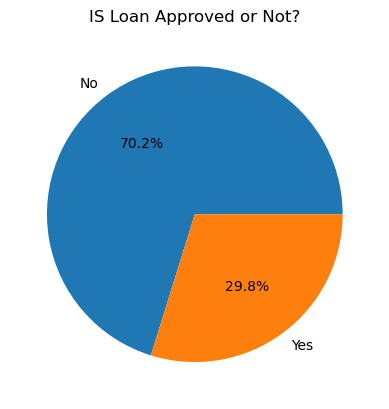

In [11]:
#how balanced our classes are?
classes_count=df["Loan_Approved"].value_counts()
plt.pie(classes_count ,labels=["No","Yes"] ,autopct="%1.1f%%")
plt.title("IS Loan Approved or Not?")

[Text(0, 0, '643'), Text(0, 0, '357')]

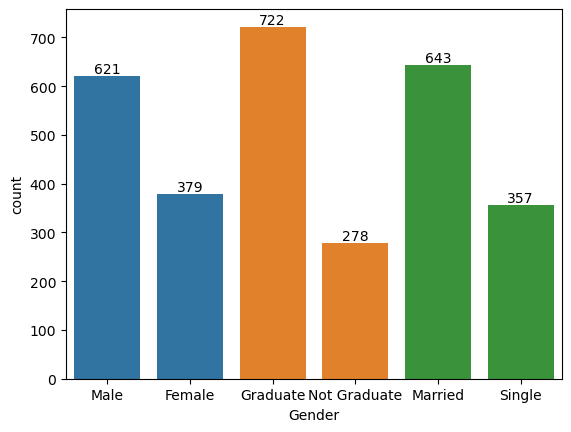

In [12]:
#Analyze categories
gender_count=df["Gender"].value_counts()
ax=sns.barplot(gender_count)
ax.bar_label(ax.containers[0])

education_count=df["Education_Level"].value_counts()
ax1=sns.barplot(education_count)
ax1.bar_label(ax1.containers[1])

martial_count=df["Marital_Status"].value_counts()
ax2=sns.barplot(martial_count)
ax2.bar_label(ax2.containers[2])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

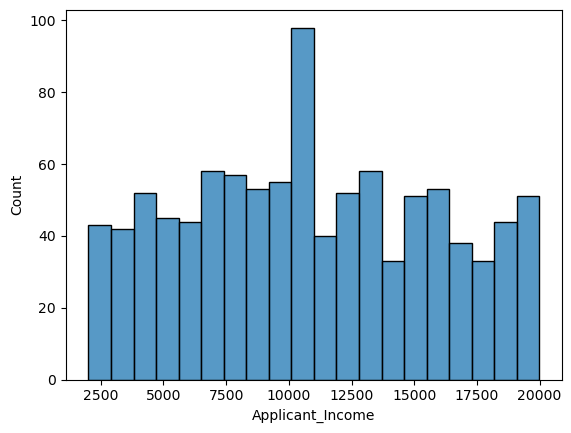

In [13]:
sns.histplot(
    data=df,
    x="Applicant_Income",
    bins=20
    
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

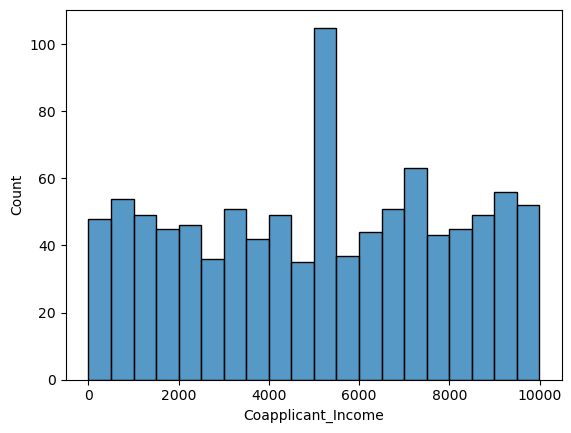

In [14]:
sns.histplot(
    data=df,
    x= "Coapplicant_Income",
    bins=20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

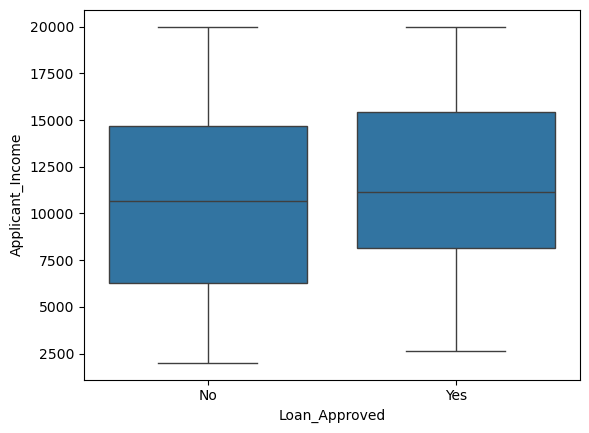

In [15]:
#Outliers-box_plot
sns.boxplot(
    data=df,
    x="Loan_Approved",
    y="Applicant_Income"
)

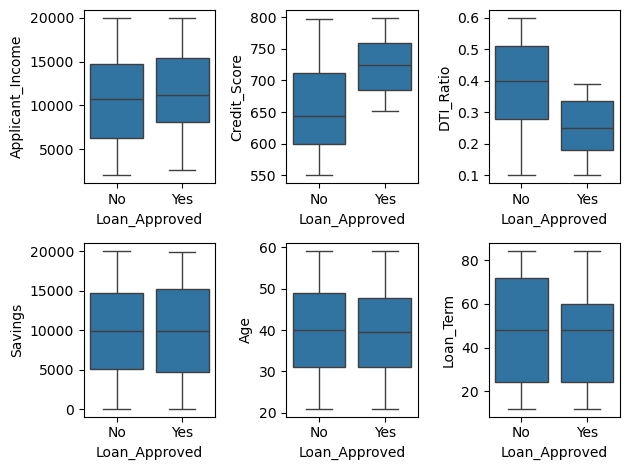

In [16]:
fig,axes=plt.subplots(2,3)

sns.boxplot(ax=axes[0,0],data =df, x="Loan_Approved" , y="Applicant_Income")
sns.boxplot(ax=axes[0,1],data =df, x="Loan_Approved" , y="Credit_Score")
sns.boxplot(ax=axes[0,2],data =df, x="Loan_Approved" , y="DTI_Ratio")
sns.boxplot(ax=axes[1,0],data =df, x="Loan_Approved" , y="Savings")
sns.boxplot(ax=axes[1,1],data =df, x="Loan_Approved" , y="Age")
sns.boxplot(ax=axes[1,2],data =df, x="Loan_Approved" , y="Loan_Term")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

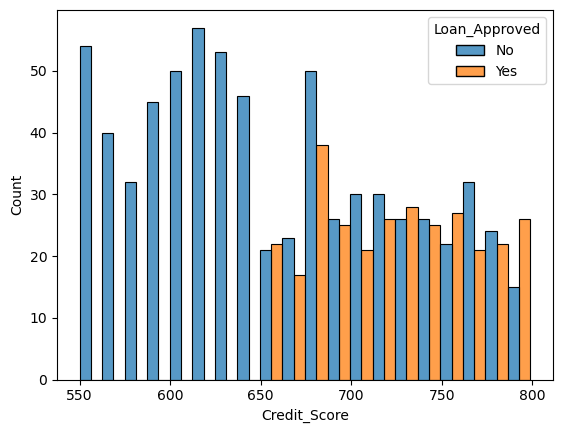

In [17]:
sns.histplot(
    data=df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)


<Axes: xlabel='Applicant_Income', ylabel='Count'>

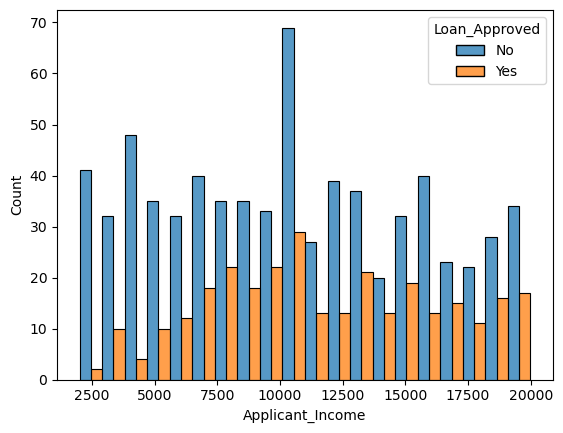

In [18]:
sns.histplot(
    data=df,
    x="Applicant_Income",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

In [19]:
#Removing Applicant Id
df=df.drop("Applicant_ID",axis=1)

In [20]:
df

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.000000,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.000000,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.000000,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.000000,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.000000,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Personal,Urban,Not Graduate,Male,Unemployed,No
996,3279.000000,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,15192.000000,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,9083.000000,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


# Encoding

In [21]:
df.head()
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

In [22]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

In [23]:
le=LabelEncoder()
df["Education_Level"]=le.fit_transform(df["Education_Level"])
df["Loan_Approved"]=le.fit_transform(df["Loan_Approved"])

In [24]:
df

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.000000,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.000000,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.000000,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.000000,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.000000,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Personal,Urban,1,Male,Unemployed,0
996,3279.000000,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Business,Urban,0,Female,Government,0
997,15192.000000,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Home,Rural,0,Male,MNC,0
998,9083.000000,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Personal,Urban,0,Male,Private,1


In [25]:
cols=["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Employer_Category","Gender"]
ohe=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")

encoded=ohe.fit_transform(df[cols])

In [26]:
ohe.get_feature_names_out(cols)

array(['Employment_Status_Salaried', 'Employment_Status_Self-employed',
       'Employment_Status_Unemployed', 'Marital_Status_Single',
       'Loan_Purpose_Car', 'Loan_Purpose_Education', 'Loan_Purpose_Home',
       'Loan_Purpose_Personal', 'Property_Area_Semiurban',
       'Property_Area_Urban', 'Employer_Category_Government',
       'Employer_Category_MNC', 'Employer_Category_Private',
       'Employer_Category_Unemployed', 'Gender_Male'], dtype=object)

In [27]:
encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cols) ,index=df.index)
df=pd.concat([df.drop(columns=cols) ,encoded_df],axis=1)


In [28]:
df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

# Correlation Heatmap

<Axes: >

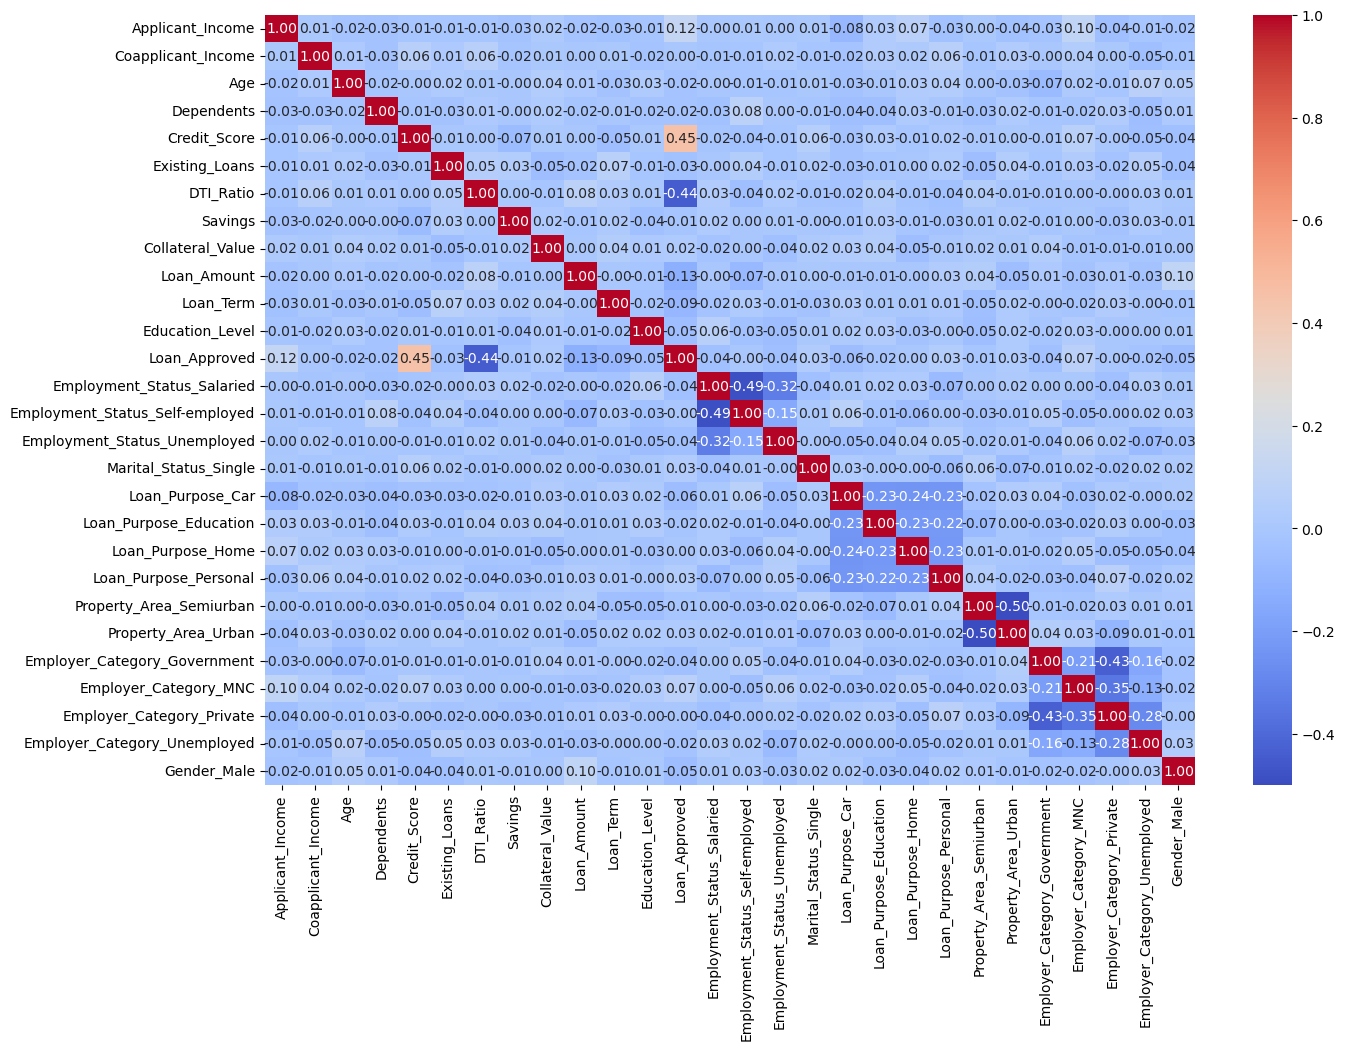

In [29]:
num_cols=df.select_dtypes(include="number")
corr_matrix=num_cols.corr()

plt.figure(figsize=(15,10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

In [30]:
num_cols.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

In [31]:
X=df.drop("Loan_Approved",axis=1)
y=df["Loan_Approved"]

In [32]:
X.head()
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Loan_Approved, dtype: int64

In [33]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [34]:
X_test.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Gender_Male
521,13023.0,6675.0,53.000000,3.0,628.0,3.0,0.347263,10051.000000,26309.0,22947.000000,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
737,15917.0,6787.0,42.000000,0.0,588.0,4.0,0.410000,922.000000,13476.0,20522.825263,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
740,7560.0,3530.0,52.000000,3.0,606.0,0.0,0.580000,9940.452632,21795.0,5876.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
660,19022.0,574.0,59.000000,0.0,725.0,4.0,0.410000,1463.000000,44498.0,8433.000000,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
411,4967.0,5797.0,39.971579,3.0,697.0,4.0,0.580000,1095.000000,3017.0,33926.000000,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


In [35]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [36]:
X_train_scaled

array([[-1.01234556e+00,  1.02716377e+00, -8.22511453e-01, ...,
        -8.59726954e-01, -3.07231582e-01, -1.29444401e+00],
       [-1.23639141e+00, -1.59187898e+00,  9.15886794e-01, ...,
        -8.59726954e-01, -3.07231582e-01,  7.72532451e-01],
       [-1.15862490e-02,  1.33606578e+00, -3.65038230e-01, ...,
         1.16316000e+00, -3.07231582e-01,  7.72532451e-01],
       ...,
       [-2.27277589e-01,  3.50089621e-01, -8.22511453e-01, ...,
         1.16316000e+00, -3.07231582e-01,  7.72532451e-01],
       [ 1.12970221e+00, -4.64700438e-01,  1.19037073e+00, ...,
        -8.59726954e-01, -3.07231582e-01,  7.72532451e-01],
       [-1.75526629e+00,  1.43417276e-02,  9.40348249e-04, ...,
        -8.59726954e-01, -3.07231582e-01,  7.72532451e-01]],
      shape=(800, 27))

In [37]:
X_test_scaled

array([[ 0.42610546,  0.55091079,  1.19037073, ...,  1.16316   ,
        -0.30723158,  0.77253245],
       [ 1.00971366,  0.58995935,  0.18392964, ...,  1.16316   ,
        -0.30723158,  0.77253245],
       [-0.67557096, -0.54558674,  1.09887608, ...,  1.16316   ,
        -0.30723158, -1.29444401],
       ...,
       [-0.67980585, -0.10106072,  1.28186537, ...,  1.16316   ,
        -0.30723158, -1.29444401],
       [-0.37650705, -0.97825874, -0.54802752, ..., -0.85972695,
        -0.30723158,  0.77253245],
       [-0.73647272, -1.24497436,  0.73289751, ...,  1.16316   ,
        -0.30723158,  0.77253245]], shape=(200, 27))

# Train & Evaluate Models


In [38]:
#Logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score,recall_score,accuracy_score,confusion_matrix,f1_score
log_model=LogisticRegression()
log_model.fit(X_train_scaled,y_train)

y_pred=log_model.predict(X_test_scaled)


print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("accuracy:",accuracy_score(y_test,y_pred))
print("f1 score:",f1_score(y_test,y_pred))
print("confusion_matrix:",confusion_matrix(y_test,y_pred))

Precision: 0.7833333333333333
Recall: 0.7704918032786885
accuracy: 0.865
f1 score: 0.7768595041322314
confusion_matrix: [[126  13]
 [ 14  47]]


In [40]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score,recall_score,accuracy_score,confusion_matrix,f1_score
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled,y_train)
y_pred=knn_model.predict(X_test_scaled)


print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("accuracy:",accuracy_score(y_test,y_pred))
print("f1 score:",f1_score(y_test,y_pred))
print("confusion_matrix:",confusion_matrix(y_test,y_pred))

Precision: 0.6274509803921569
Recall: 0.5245901639344263
accuracy: 0.76
f1 score: 0.5714285714285714
confusion_matrix: [[120  19]
 [ 29  32]]


In [43]:
#Naive Bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import precision_score,recall_score,accuracy_score,confusion_matrix,f1_score
gnb_model=GaussianNB()
gnb_model.fit(X_train_scaled,y_train)
y_pred=gnb_model.predict(X_test_scaled)

In [44]:
y_pred

array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0])

In [45]:

print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("accuracy:",accuracy_score(y_test,y_pred))
print("f1 score:",f1_score(y_test,y_pred))
print("confusion_matrix:",confusion_matrix(y_test,y_pred))

Precision: 0.8035714285714286
Recall: 0.7377049180327869
accuracy: 0.865
f1 score: 0.7692307692307693
confusion_matrix: [[128  11]
 [ 16  45]]


# Feature Engineering


In [48]:
# Add or transform Features
df["DTI_Ratio_sq"]=df["DTI_Ratio"] **2
df["Credit_Score_sq"]=df["Credit_Score"] **2


X=df.drop(columns=["Loan_Approved","Credit_Score","DTI_Ratio"])
y=df["Loan_Approved"]

#Train_Test_Split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [49]:
X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Existing_Loans,Savings,Collateral_Value,Loan_Amount,Loan_Term,Education_Level,...,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Gender_Male,DTI_Ratio_sq,Credit_Score_sq
29,5890.000000,8041.0,31.000000,0.0,0.000000,11906.0,8150.000000,29287.000000,12.0,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0121,363609.000000
535,4779.000000,529.0,50.000000,0.0,0.000000,5369.0,5430.000000,14786.000000,72.0,1,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0441,376996.000000
695,10852.571579,8927.0,36.000000,0.0,4.000000,3186.0,24802.792632,20522.825263,48.0,1,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0484,341056.000000
557,2384.000000,2113.0,39.971579,1.0,4.000000,11882.0,48542.000000,13312.000000,24.0,0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.1156,527076.000000
836,5228.000000,5249.0,42.000000,1.0,1.950526,17669.0,24802.792632,13906.000000,84.0,0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0324,457021.542187


In [50]:
log_model=LogisticRegression()
log_model.fit(X_train_scaled,y_train)

y_pred=log_model.predict(X_test_scaled)

print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("accuracy:",accuracy_score(y_test,y_pred))
print("f1 score:",f1_score(y_test,y_pred))
print("confusion_matrix:",confusion_matrix(y_test,y_pred))

Precision: 0.8035714285714286
Recall: 0.7377049180327869
accuracy: 0.865
f1 score: 0.7692307692307693
confusion_matrix: [[128  11]
 [ 16  45]]
